# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [21]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [22]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

path = kagglehub.dataset_download('uciml/mushroom-classification')

print("Dataset path:", path)

Dataset path: /home/irzam/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [23]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.

data = pd.read_csv(path + '/mushrooms.csv')
print(data.info())

print("\nJumlah missing value per kolom:")
print(data.isnull().sum())

print("\nJumlah duplikasi baris:", data.duplicated().sum())

print("\nBeberapa baris pertama dataset:")
print(data.head())

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [24]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

print("\nJumlah nilai unik pada setiap fitur:")
for column in data.columns:
    print(f"{column}: {data[column].nunique()}")


Jumlah nilai unik pada setiap fitur:
class: 2
cap-shape: 6
cap-surface: 4
cap-color: 10
bruises: 2
odor: 9
gill-attachment: 2
gill-spacing: 2
gill-size: 2
gill-color: 12
stalk-shape: 2
stalk-root: 5
stalk-surface-above-ring: 4
stalk-surface-below-ring: 4
stalk-color-above-ring: 9
stalk-color-below-ring: 9
veil-type: 1
veil-color: 4
ring-number: 3
ring-type: 5
spore-print-color: 9
population: 6
habitat: 7


Text(0.5, 1.0, 'Distribusi Kelas Target (class)')

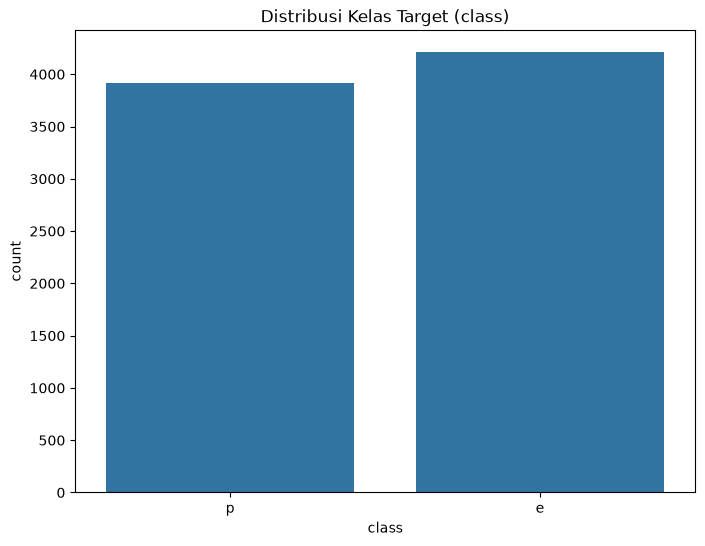

In [25]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=data)
plt.title('Distribusi Kelas Target (class)')

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

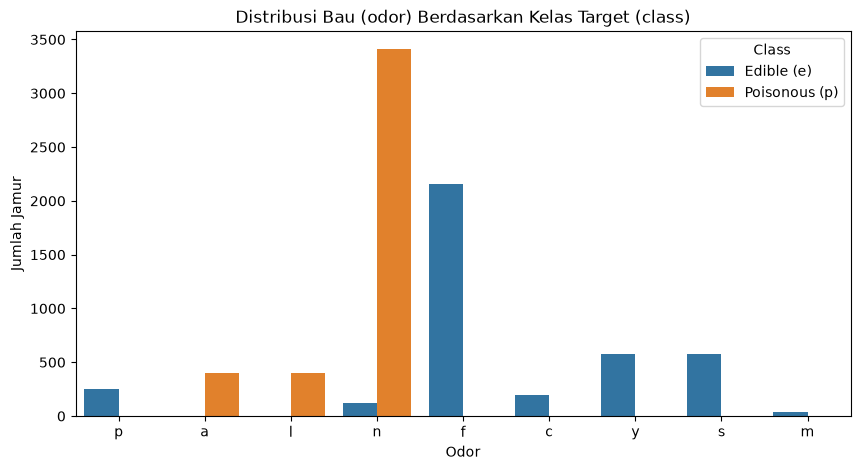

In [26]:
# Eksplorasi hubungan antara fitur penting (seperti odor) dengan kelas target.
plt.figure(figsize=(10, 5))
sns.countplot(x='odor', hue='class', data=data)
plt.title('Distribusi Bau (odor) Berdasarkan Kelas Target (class)')
plt.xlabel('Odor')
plt.ylabel('Jumlah Jamur')
plt.legend(title='Class', labels=['Edible (e)', 'Poisonous (p)'])
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [27]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

# Memilih strategi menjadikan nilai '?' sebagai kategori tersendiri ('missing')
data['stalk-root'] = data['stalk-root'].replace('?', 'missing')
print("Nilai unik stalk-root setelah penanganan missing value:")
print(data['stalk-root'].value_counts())

Nilai unik stalk-root setelah penanganan missing value:
stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64


In [28]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

for col in data.columns:
    if data[col].nunique() == 1:
        print(f"Fitur '{col}' hanya memiliki satu nilai unik dan akan didrop")
        data.drop(columns=[col], inplace=True)

Fitur 'veil-type' hanya memiliki satu nilai unik dan akan didrop


In [29]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=['class'])
y = data['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
X_train_ord = ordinal_encoder.fit_transform(X_train)
X_test_ord = ordinal_encoder.transform(X_test)

In [31]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

from sklearn.preprocessing import OneHotEncoder

ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe_encoder.fit_transform(X_train)
X_test_ohe = ohe_encoder.transform(X_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [32]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix

model_cnb = CategoricalNB()
model_cnb.fit(X_train_ord, y_train)

# Lakukan prediksi pada test set dan tampilkan classification report serta confusion matrix.

y_pred_cnb = model_cnb.predict(X_test_ord)

print("Classification Report:")
print(classification_report(y_test, y_pred_cnb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Confusion Matrix:
[[835   7]
 [ 81 702]]


In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cnb = model_cnb.predict(X_test_ord)
y_prob_cnb = model_cnb.predict_proba(X_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [34]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
model_bnb = BernoulliNB()
model_bnb.fit(X_train_ohe, y_train)

# Lakukan prediksi pada test set dan tampilkan classification report serta confusion matrix.
y_pred_bnb = model_bnb.predict(X_test_ohe)

print("Classification Report:")
print(classification_report(y_test, y_pred_bnb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bnb))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       842
           1       0.98      0.88      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.94      0.93      0.93      1625

Confusion Matrix:
[[829  13]
 [ 96 687]]


In [35]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = model_bnb.predict(X_test_ohe)
y_prob_bnb = model_bnb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [36]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
model_mnb = MultinomialNB()
model_mnb.fit(X_train_ohe, y_train)

# Lakukan prediksi pada test set dan tampilkan classification report serta confusion matrix.
y_pred_mnb = model_mnb.predict(X_test_ohe)

print("Classification Report:")
print(classification_report(y_test, y_pred_mnb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mnb))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625

Confusion Matrix:
[[835   7]
 [ 81 702]]


In [37]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = model_mnb.predict(X_test_ohe)
y_prob_mnb = model_mnb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [38]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
metrics_data = {
    'Model': ['Categorical NB', 'Bernoulli NB', 'Multinomial NB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_cnb),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_mnb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_cnb),
        precision_score(y_test, y_pred_bnb),
        precision_score(y_test, y_pred_mnb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_cnb),
        recall_score(y_test, y_pred_bnb),
        recall_score(y_test, y_pred_mnb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_cnb),
        f1_score(y_test, y_pred_bnb),
        f1_score(y_test, y_pred_mnb)
    ]
}

df_eval = pd.DataFrame(metrics_data)
print("Perbandingan Metrik Evaluasi:")
display(df_eval)

Perbandingan Metrik Evaluasi:


,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


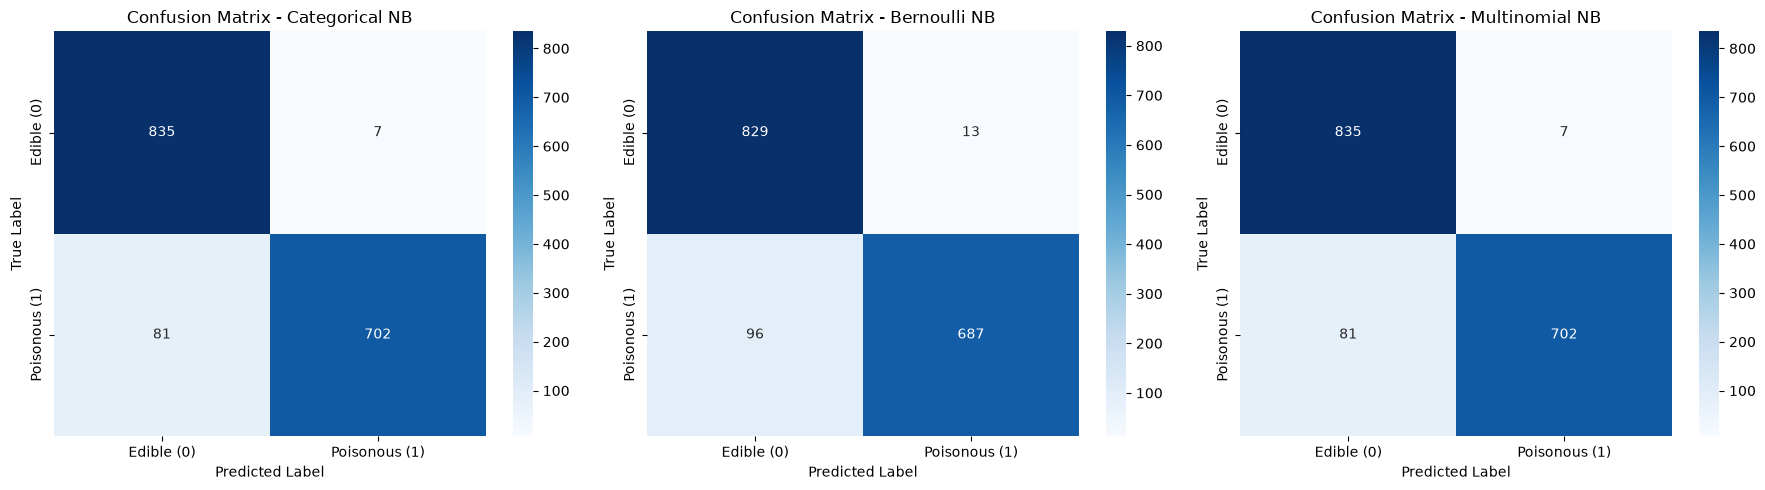

In [39]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_preds = [
    ('Categorical NB', y_pred_cnb),
    ('Bernoulli NB', y_pred_bnb),
    ('Multinomial NB', y_pred_mnb)
]

for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Edible (0)', 'Poisonous (1)'],
                yticklabels=['Edible (0)', 'Poisonous (1)'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

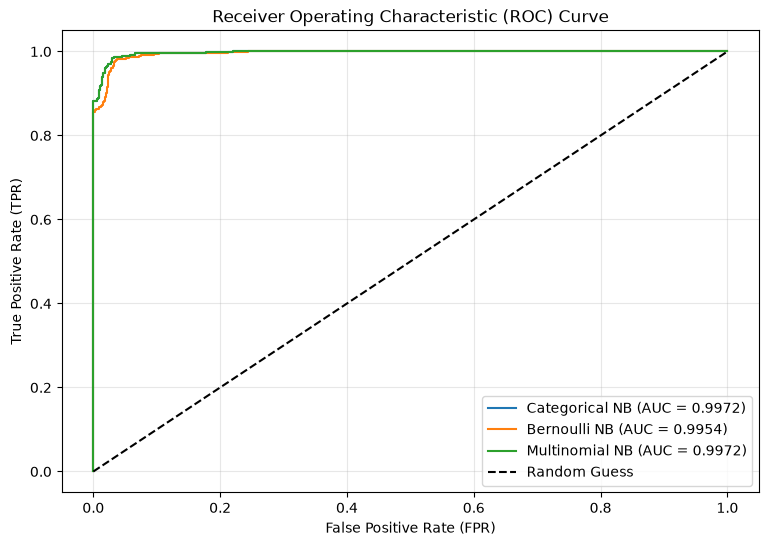

In [40]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
model_probs = [
    ('Categorical NB', y_prob_cnb),
    ('Bernoulli NB', y_prob_bnb),
    ('Multinomial NB', y_prob_mnb)
]

plt.figure(figsize=(9, 6))

for name, prob in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Categorical NB dan Multinomial NB memberikan hasil terbaik dengan akurasi data uji sebesar 94.58% dan F1-Score 94.10%, disusul oleh Bernoulli NB dengan akurasi 93.29%.

Categorical NB dan Multinomial NB unggul karena representasi data yang digunakan mampu mencerminkan proporsi kategori secara langsung tanpa penalti. Sementara itu, Bernoulli NB menghasilkan recall yang sedikit lebih rendah (87.74%) karena model ini turut memperhitungkan ketiadaan fitur (nilai 0) dalam perhitungannya, yang menyebabkan jamur beracun yang salah terprediksi sebagai edible (False Negative) menjadi sedikit lebih banyak.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Model terbaik didapatkan pada Categorical NB (dengan OrdinalEncoder) dan Multinomial NB (dengan OneHotEncoder), menghasilkan akurasi data uji sebesar 94.58% serta AUC 0.9972. Model bekerja sangat baik dalam membedakan jamur edible dan poisonous, dengan tingkat kesalahan (False Negative) yang rendah.